In [1]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

from social_graph.describe import persona_significance
from social_graph.pipeline import *
from social_graph.preprocessing import *
from social_graph.metrics import *
from social_graph.analysis import *

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
conn = sqlite3.connect('data/exp_set_2/database_server.db')

## Personality-based persona & basic analysis pipeline

Data loading ...

Number of users: 1000
Total actions: 20653
Follow actions: 19661
Unfollow actions: 992
Number of rounds: 51
Number of posts: 155568

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1720
k=3 silhouette=0.1729
k=4 silhouette=0.2169
k=5 silhouette=0.2234
k=6 silhouette=0.2516
k=7 silhouette=0.2478
k=8 silhouette=0.2728
k=9 silhouette=0.3159


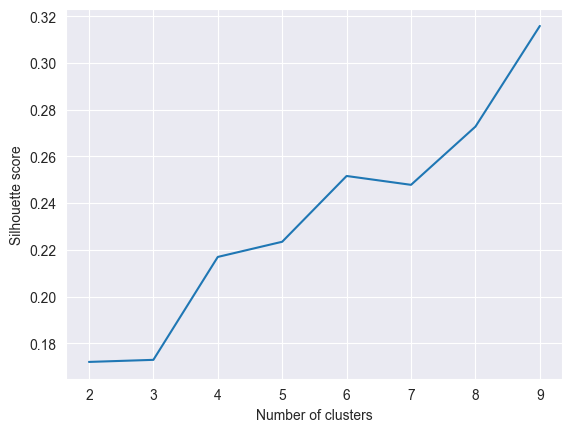


Done!


In [3]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism']
personas, features_df, follow = run_simulation_preprocessing(conn, feature_cols=features_cols)

Persona creation ...

persona
Persona_1    234
Persona_2    186
Persona_6    158
Persona_3    156
Persona_4    150
Persona_5    116
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 1.2307801955218897e-54
conscientiousness: 4.9913527424962484e-83
extroversion: 2.390919307008131e-122
agreeableness: 5.636350347714726e-110
neuroticism: 3.4064796296913e-113


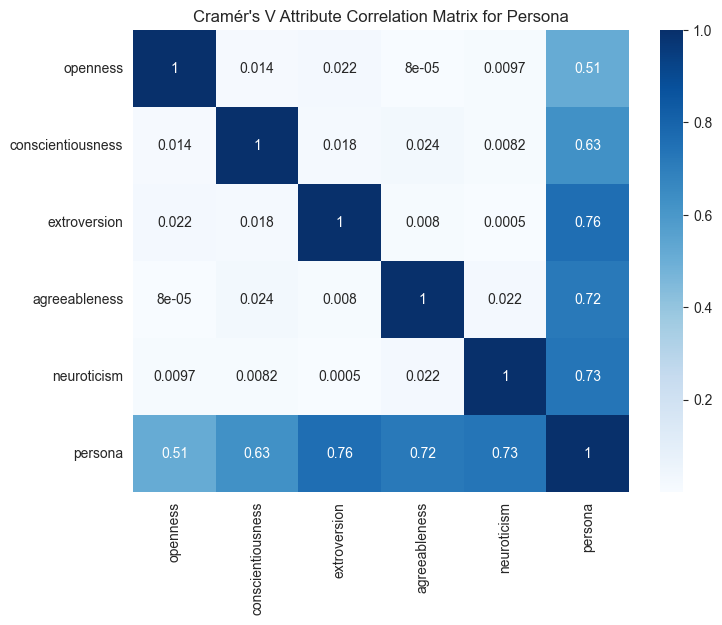

In [4]:
k_best = 6
description, persona_dict = cluster_persona_and_analyse(personas, features_df, k_best, feature_cols=features_cols)

In [5]:
description

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous
persona,,,,,,,,,,
Persona_1,0.722222,0.277778,0.713675,0.286325,0.846154,0.153846,0.854701,0.145299,0.136752,0.863248
Persona_2,0.543011,0.456989,0.000000,1.000000,0.854839,0.145161,0.333333,0.666667,0.827957,0.172043
Persona_3,0.423077,0.576923,0.365385,0.634615,0.211538,0.788462,0.000000,1.000000,0.000000,1.000000
Persona_4,0.233333,0.766667,1.000000,0.000000,0.773333,0.226667,0.166667,0.833333,0.786667,0.213333
Persona_5,1.000000,0.000000,0.500000,0.500000,0.000000,1.000000,0.482759,0.517241,1.000000,0.000000
Persona_6,0.208861,0.791139,0.417722,0.582278,0.000000,1.000000,1.000000,0.000000,0.373418,0.626582


In [6]:
global_metrics, summary = build_graph_and_analyse(follow, persona_dict)

Graph creation ...

Number of nodes: 983
Number of edges: 18691
Number of connective components: 3
Components sizes: [981, 1, 1]
Number of nodes (LCC): 981
Number of edges (LCC): 18691

Global metrics ...

Mean degree: 38.03
Density: 0.0194
Diameter: 5
Avg. shortest path: 2.510
Modularity score: 0.136
Persona assortativity: 0.0007105317671753645

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.2579
out_degree statistics: p = 0.3330
total_degree statistics: p = 0.3233
betweenness statistics: p = 0.4372
eigenvector statistics: p = 0.3288
pagerank statistics: p = 0.3421
kcore statistics: p = 0.3740


In [7]:
global_metrics

,Simulation
Metric,
Mean degree,38.028484
Density,0.019363
Diameter,5.000000
Avg. shortest path,2.509994
Modularity,0.135993
Persona assortativity,0.000711


In [8]:
summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,
Persona_1,228,17.653509,17.732456,35.385965,0.001361,0.017503,0.000953,16.311404,0.935092
Persona_2,183,17.743169,16.945355,34.688525,0.001499,0.017641,0.000969,15.732240,0.950239
Persona_3,153,25.052288,24.124183,49.176471,0.002370,0.023867,0.001288,18.444444,1.263995
Persona_4,149,18.402685,17.912752,36.315436,0.001624,0.017731,0.000995,15.657718,0.975863
Persona_5,111,18.090090,18.873874,36.963964,0.001461,0.018302,0.000974,16.234234,0.955018
Persona_6,157,18.063694,19.694268,37.757962,0.001655,0.019423,0.000968,16.057325,0.949704


### Null model validation

In [9]:
G, G_lcc = create_graph(follow)

nx.set_node_attributes(G, persona_dict, "persona")
nx.set_node_attributes(G_lcc, persona_dict, "persona")

Number of nodes: 983
Number of edges: 18691
Number of connective components: 3
Components sizes: [981, 1, 1]
Number of nodes (LCC): 981
Number of edges (LCC): 18691


In [10]:
# null_distributions = persona_permutation_test(G_lcc, summary, n_perm=500, seed=42)

In [11]:
# p_values = permutation_pvalues(summary, null_distributions) # set a seed in future!!!
# p_values

In [12]:
# z_scores = permutation_zscores(summary, null_distributions)
# z_scores

### PCA - Big Five coloured by personas

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_df)

In [14]:
plot_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'persona': personas['persona']
})

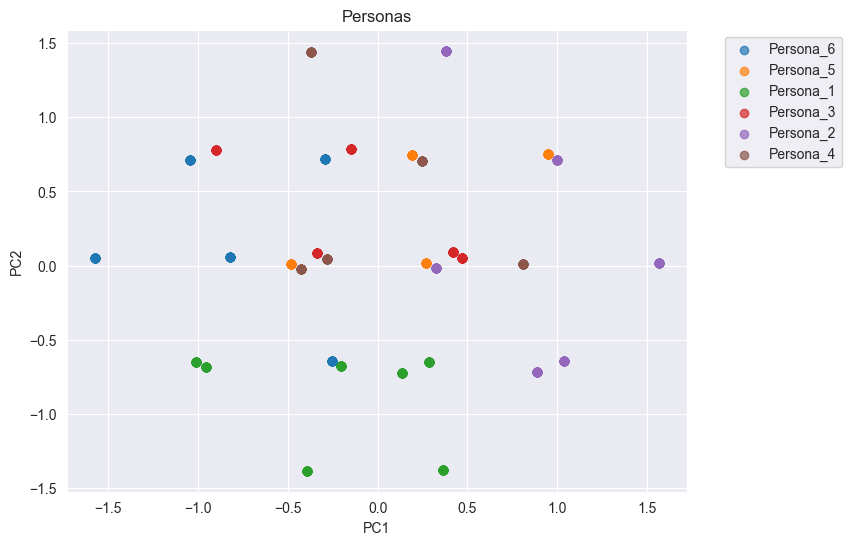

In [15]:
plot_pca(plot_df, colour_by='persona', title='Personas')

## Features engineering

Based on *personas_on_behaviour.ipynb*.

In [16]:
personas = personas[['id', 'persona']].rename(columns={'id': 'follower_id'})

follow = follow.merge(personas, on='follower_id', how='left')
follow.head()

,user_id,follower_id,id,action,round,persona
0,744,856,1,follow,1,Persona_4
1,27,80,2,follow,1,Persona_6
2,529,27,3,follow,1,Persona_1
3,872,911,4,follow,1,Persona_2
4,249,872,5,follow,1,Persona_4


### Lifespan

In [17]:
lifespan = lifespan_analysis(follow, agg_by='follower_id')
lifespan.head()

Invalid unfollow action for users 67 -> 216: unfollow
Invalid unfollow action for users 118 -> 758: unfollow
Invalid unfollow action for users 118 -> 905: unfollow
Invalid unfollow action for users 123 -> 774: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 275 -> 708: unfollow
Invalid unfollow action for users 330 -> 847: unfollow
Invalid unfollow action for users 342 -> 587: unfollow
Invalid unfollow action for users 342 -> 587: unfollow
Invalid unfollow action for users 343 -> 845: unfollow
Invalid unfollow action for users 354 -> 342: unfollow
Invalid unfollow action for users 356 -> 587: unfollow
Invalid unfollow action for users 359 -> 331: unfollow
Invalid unfollow action for users 438 -> 342: unfollow
Invalid unfollow action for users 438 -> 342: unfollow
Invalid unf

,follower_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate
0,2,13,13,0,NaN,NaN,NaN,1.000000
1,3,4,4,0,NaN,NaN,NaN,1.000000
2,4,20,20,0,NaN,NaN,NaN,1.000000
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500


### Follow

In [18]:
local_metrics, summary = calculate_local_metrics(G_lcc)
local_metrics.drop(columns=['persona'], inplace=True)
local_metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore
0,856,141,114,255,0.016564,0.110036,0.006396,41
1,744,154,143,297,0.024440,0.124465,0.007169,41
2,80,51,53,104,0.004106,0.059890,0.002546,41
3,27,104,102,206,0.014151,0.092359,0.004663,41
4,529,109,99,208,0.013711,0.096607,0.004975,41


<Axes: >

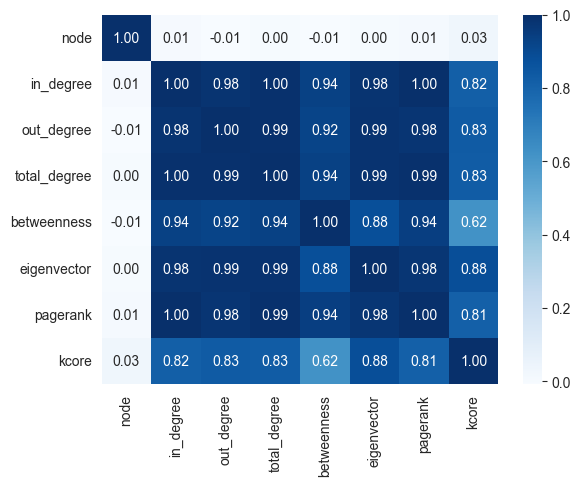

In [19]:
corr = local_metrics.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')

### Posts

In [20]:
posts = pd.read_sql("SELECT * FROM post", conn)
personas.rename(columns={'follower_id': 'user_id'}, inplace=True)
posts = posts.merge(personas, on='user_id', how='left')

posts = posts.drop_duplicates(
    subset=['user_id', 'tweet', 'round']
)
posts.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
0,1,Just finished bingewatching a new series on Ne...,None,961,-1,1,1,None,-1,None,0,Persona_1
1,2,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,2,1,None,-1,None,0,Persona_4
2,3,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,3,1,None,-1,None,0,Persona_4
6,7,@AndrewJohnson I'm always looking for a new sh...,None,856,1,1,1,None,-1,None,0,Persona_4
7,8,@AndrewJohnson Still waiting on that title! I'...,None,856,1,1,1,None,-1,None,0,Persona_4


In [21]:
posts_summary = posts_analysis(posts)
posts_summary.head()

,user_id,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,70,0,15,85,25.094118,Persona_6
1,3,22,1,0,23,30.956522,Persona_5
2,4,75,1,2,78,29.038462,Persona_1
3,5,1038,58,69,1165,26.466953,Persona_3
4,6,153,20,25,198,24.606061,Persona_6


### New features

In [22]:
local_metrics.rename(columns={'node': 'user_id'}, inplace=True)
lifespan.rename(columns={'follower_id': 'user_id'}, inplace=True)

personas_features = (lifespan.
               merge(local_metrics, on='user_id').
               merge(posts_summary, on='user_id'))

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,13,13,0,NaN,NaN,NaN,1.000000,12,13,...,5.842536e-05,0.015870,0.000672,19,70,0,15,85,25.094118,Persona_6
1,3,4,4,0,NaN,NaN,NaN,1.000000,1,4,...,4.417667e-07,0.004818,0.000194,5,22,1,0,23,30.956522,Persona_5
2,4,20,20,0,NaN,NaN,NaN,1.000000,7,20,...,1.648232e-04,0.015062,0.000478,19,75,1,2,78,29.038462,Persona_1
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252,130,130,...,2.151160e-02,0.107608,0.005960,41,1038,58,69,1165,26.466953,Persona_3
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500,21,30,...,3.493630e-03,0.025537,0.001311,27,153,20,25,198,24.606061,Persona_6


In [23]:
days = 50

posts_columns = ['positive_posts', 'neutral_posts', 'negative_posts']

for column in posts_columns:
    personas_features[column + '_ratio'] = personas_features[column] / personas_features['total_posts']

personas_features['posts_per_day'] = personas_features['total_posts'] / days

personas_features['in_out_degree_ratio'] = personas_features['in_degree'] / (personas_features['out_degree'] + 1)

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,neutral_posts,negative_posts,total_posts,avg_word_count,persona,positive_posts_ratio,neutral_posts_ratio,negative_posts_ratio,posts_per_day,in_out_degree_ratio
0,2,13,13,0,NaN,NaN,NaN,1.000000,12,13,...,0,15,85,25.094118,Persona_6,0.823529,0.000000,0.176471,1.70,0.857143
1,3,4,4,0,NaN,NaN,NaN,1.000000,1,4,...,1,0,23,30.956522,Persona_5,0.956522,0.043478,0.000000,0.46,0.200000
2,4,20,20,0,NaN,NaN,NaN,1.000000,7,20,...,1,2,78,29.038462,Persona_1,0.961538,0.012821,0.025641,1.56,0.333333
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252,130,130,...,58,69,1165,26.466953,Persona_3,0.890987,0.049785,0.059227,23.30,0.992366
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500,21,30,...,20,25,198,24.606061,Persona_6,0.772727,0.101010,0.126263,3.96,0.677419


In [24]:
selected_features = personas_features[['user_id', 'persona', 'in_out_degree_ratio', 'betweenness', 'kcore',
                    'neutral_posts_ratio', 'negative_posts_ratio', 'posts_per_day', 'lifespan_mean', 'survival_rate', 'avg_word_count']]

selected_features.set_index('user_id', inplace=True)
selected_features.head()

,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
user_id,,,,,,,,,,
2,Persona_6,0.857143,5.842536e-05,19,0.000000,0.176471,1.70,NaN,1.000000,25.094118
3,Persona_5,0.200000,4.417667e-07,5,0.043478,0.000000,0.46,NaN,1.000000,30.956522
4,Persona_1,0.333333,1.648232e-04,19,0.012821,0.025641,1.56,NaN,1.000000,29.038462
5,Persona_3,0.992366,2.151160e-02,41,0.049785,0.059227,23.30,13.319444,0.935252,26.466953
6,Persona_6,0.677419,3.493630e-03,27,0.101010,0.126263,3.96,1.020833,0.937500,24.606061


<Axes: >

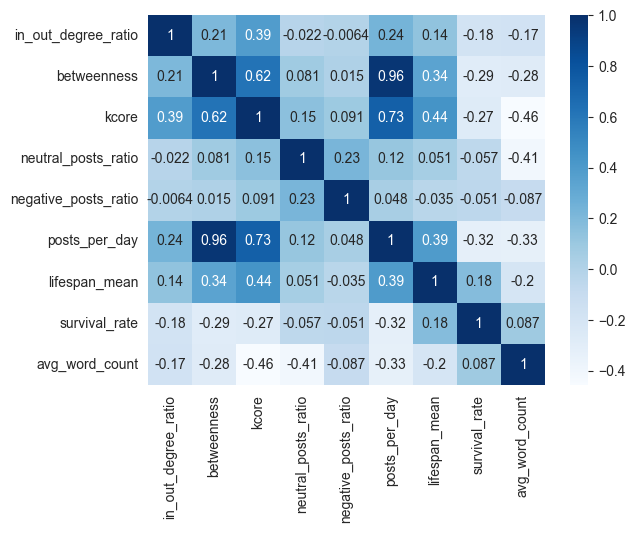

In [25]:
corr = selected_features.drop(columns=['persona'], inplace=False).corr()
sns.heatmap(corr, annot=True, cmap='Blues')

## Old persona vs. behavioral features

In [26]:
selected_features.groupby('persona').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
persona,,,,,,,,,
Persona_1,0.841252,0.001423,16.986239,0.055433,0.120497,2.903119,4.956564,0.979509,28.656576
Persona_2,0.861952,0.001516,15.895028,0.034730,0.112633,2.779116,4.720070,0.975123,30.148221
Persona_3,0.866491,0.002417,18.780000,0.028364,0.067079,4.233600,6.270321,0.972730,29.532069
Persona_4,0.834807,0.001657,15.958904,0.031075,0.070499,2.979315,7.081917,0.982293,29.731819
Persona_5,0.737688,0.001474,16.372727,0.067797,0.087171,3.098182,4.969607,0.977436,26.263508
Persona_6,0.755675,0.001744,16.825503,0.075590,0.152222,3.737450,5.390613,0.969745,28.139047


In [27]:
selected_features['lifespan_mean'].fillna(0, inplace=True)

for col in selected_features.drop(columns=['persona'], inplace=False):
    groups = [
        selected_features[selected_features['persona'] == p][col]
        for p in selected_features['persona'].unique()
    ]

    stat_diff = kruskal(*groups)
    print(f"{col} statistics: p = {stat_diff.pvalue:.4f}")

in_out_degree_ratio statistics: p = 0.0193
betweenness statistics: p = 0.3907
kcore statistics: p = 0.3250
neutral_posts_ratio statistics: p = 0.0000
negative_posts_ratio statistics: p = 0.0000
posts_per_day statistics: p = 0.2961
lifespan_mean statistics: p = 0.1277
survival_rate statistics: p = 0.2465
avg_word_count statistics: p = 0.0000


C:\Users\magda\AppData\Local\Temp\ipykernel_24352\280539477.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_features['lifespan_mean'].fillna(0, inplace=True)
C:\Users\magda\AppData\Local\Temp\ipykernel_24352\280539477.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['lifespan_mean'].fillna(0, inplace=True)


## Personas on behaviour

In [28]:
features_scaled = selected_features.copy().drop(columns=['persona'])

features_scaled['posts_per_day'] = np.log1p(features_scaled['posts_per_day'])
features_scaled['betweenness'] = np.log1p(features_scaled['betweenness'])

# Fill Nan in lifespan_median with zeros.
# features_scaled['lifespan_median'].fillna(0, inplace=True)

features_scaled = StandardScaler().fit_transform(features_scaled)

k=2 silhouette=0.3487
k=3 silhouette=0.2251
k=4 silhouette=0.2011
k=5 silhouette=0.2459
k=6 silhouette=0.2177
k=7 silhouette=0.2128
k=8 silhouette=0.1985
k=9 silhouette=0.1989


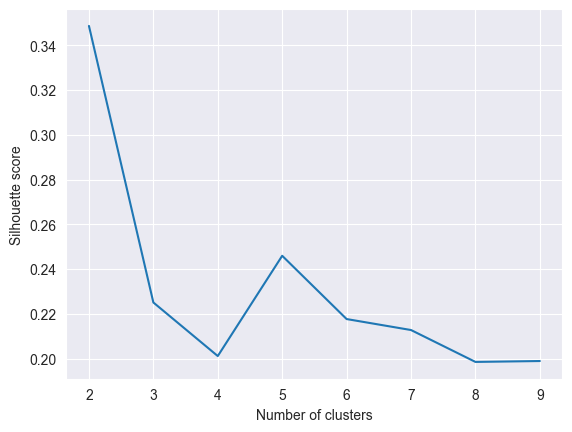

In [29]:
search_best_number_of_personae(features_scaled)

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(features_scaled)
selected_features['kmeans_label'] = labels
selected_features.head()

C:\Users\magda\AppData\Local\Temp\ipykernel_24352\2788476733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['kmeans_label'] = labels


,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count,kmeans_label
user_id,,,,,,,,,,,
2,Persona_6,0.857143,5.842536e-05,19,0.000000,0.176471,1.70,0.000000,1.000000,25.094118,1
3,Persona_5,0.200000,4.417667e-07,5,0.043478,0.000000,0.46,0.000000,1.000000,30.956522,0
4,Persona_1,0.333333,1.648232e-04,19,0.012821,0.025641,1.56,0.000000,1.000000,29.038462,0
5,Persona_3,0.992366,2.151160e-02,41,0.049785,0.059227,23.30,13.319444,0.935252,26.466953,2
6,Persona_6,0.677419,3.493630e-03,27,0.101010,0.126263,3.96,1.020833,0.937500,24.606061,1


In [31]:
selected_features['kmeans_label'].value_counts()

kmeans_label
0    437
1    363
3    106
2     48
Name: count, dtype: int64

In [32]:
selected_features.drop(columns=['persona'], inplace=False).groupby('kmeans_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
kmeans_label,,,,,,,,,
0,0.655191,0.000181,7.874142,0.020839,0.070559,0.682746,0.022216,0.992581,31.044280
1,0.929735,0.000771,18.506887,0.076075,0.141754,2.166667,0.146694,0.973126,27.290564
2,1.069839,0.017402,41.000000,0.064835,0.100868,24.131667,10.150204,0.920168,25.704099
3,1.036211,0.003935,36.867925,0.057064,0.114595,8.117170,9.150914,0.945226,26.883958


### Compare with old personas

<Axes: xlabel='kmeans_label', ylabel='persona'>

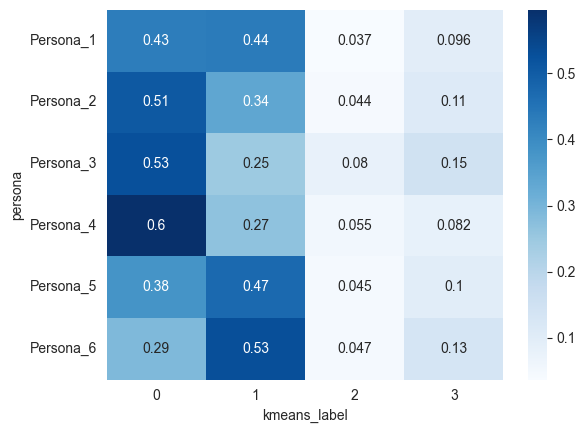

In [33]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

<Axes: xlabel='kmeans_label', ylabel='persona'>

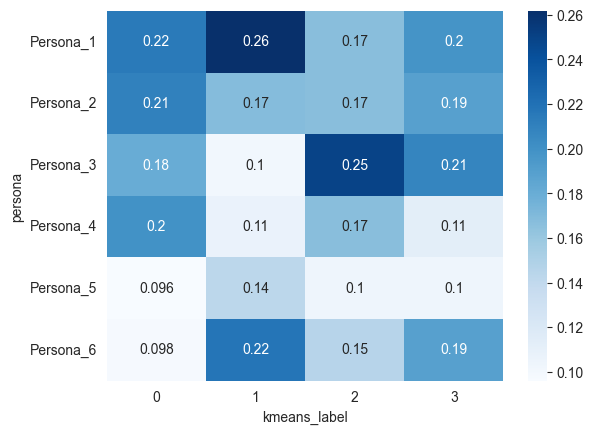

In [34]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [35]:
adjusted_rand_score(selected_features['persona'], selected_features['kmeans_label'])

0.014225319237404261

## Temporal stability of agents behaviour

In [36]:
window = 5
days = [10, 20, 35, 50]

### Follow

In [37]:
global_summary = []
summaries = []

for day in days:
    follow_t = follow[(follow['round'] <= day * 24) & (follow['round'] > (day - window) * 24)]
    print(len(follow_t))

    global_metrics, summary = build_graph_and_analyse(follow_t, persona_dict)
    global_metrics['day'] = day
    summary['day'] = day

    global_summary.append(global_metrics)
    summaries.append(summary)

global_summary_df = pd.concat(global_summary)
summaries_df = pd.concat(summaries)

2401
Graph creation ...

Number of nodes: 628
Number of edges: 2252
Number of connective components: 10
Components sizes: [612, 2, 1, 2, 1, 1, 2, 1, 4, 2]
Number of nodes (LCC): 612
Number of edges (LCC): 2245

Global metrics ...

Mean degree: 7.17
Density: 0.0057
Diameter: 8
Avg. shortest path: 3.553
Modularity score: 0.397
Persona assortativity: 0.0013818873185153923

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.0723
out_degree statistics: p = 0.4592
total_degree statistics: p = 0.1465
betweenness statistics: p = 0.3434
eigenvector statistics: p = 0.0592
pagerank statistics: p = 0.0782
kcore statistics: p = 0.0888
2235
Graph creation ...

Number of nodes: 632
Number of edges: 2052
Number of connective components: 11
Components sizes: [611, 3, 3, 1, 3, 2, 2, 2, 1, 2, 2]
Number of nodes (LCC): 611
Number of edges (LCC): 2041

Global metrics ...

Mean degree: 6.49
Density: 0.0051
Diameter: 9
Avg. shortest path: 3.650
Modularity score: 0.43

In [38]:
rank_df = summaries_df.copy()

metrics = ['mean_in_degree', 'mean_out_degree', 'mean_total_degree', 'mean_betweenness', 'mean_eigenvector', 'mean_pagerank', 'mean_kcore']

for col in metrics:
    rank_df[col + '_rank'] = rank_df.groupby('day')[col] \
                                   .rank(ascending=False, method='min')

rank_summary = rank_df.groupby('persona')[[col + '_rank' for col in metrics]].agg(['mean', 'std'])

for metric in [col + '_rank' for col in metrics]:
    rank_summary[(metric, 'cv')] = (
        rank_summary[(metric, 'std')] /
        rank_summary[(metric, 'mean')]
    )

print(rank_summary)

          mean_in_degree_rank           mean_out_degree_rank            \
                         mean       std                 mean       std   
persona                                                                  
Persona_1                5.50  0.577350                 4.75  1.892969   
Persona_2                4.25  1.500000                 5.00  0.816497   
Persona_3                1.00  0.000000                 1.75  1.500000   
Persona_4                4.75  0.957427                 4.00  0.816497   
Persona_5                3.25  0.957427                 3.75  1.500000   
Persona_6                2.25  0.500000                 1.75  0.500000   

          mean_total_degree_rank           mean_betweenness_rank            \
                            mean       std                  mean       std   
persona                                                                      
Persona_1                   5.25  0.957427                  5.75  0.500000   
Persona_2            

### Posts

In [39]:
post_counts = []

for day in days:
    posts_t = posts[(posts['round'] <= day * 24) & (posts['round'] > (day - window) * 24)]
    print(len(posts_t))

    counts = posts_t.groupby('persona')['persona'].count().reset_index(name='count')
    counts = pd.DataFrame(counts)
    counts['ratio'] = counts['count'] / len(posts_t)
    counts['day'] = day
    post_counts.append(counts)

post_counts = pd.concat(post_counts)
post_counts

15873
15578
15311
15940


,persona,count,ratio,day
0,Persona_1,3385,0.213255,10
1,Persona_2,2518,0.158634,10
2,Persona_3,3178,0.200214,10
3,Persona_4,2233,0.140679,10
4,Persona_5,1595,0.100485,10
5,Persona_6,2964,0.186732,10
0,Persona_1,3236,0.207729,20
1,Persona_2,2577,0.165426,20
2,Persona_3,3130,0.200924,20
3,Persona_4,2129,0.136667,20


In [40]:
post_summary = post_counts[['persona', 'ratio']].groupby('persona').agg(
    mean_ratio=('ratio', 'mean'),
    std_ratio=('ratio', 'std')
)
post_summary['cv_ratio'] = (
    post_summary['std_ratio'] /
    post_summary['mean_ratio']
)

post_summary

,mean_ratio,std_ratio,cv_ratio
persona,,,
Persona_1,0.206261,0.006943,0.033663
Persona_2,0.160486,0.003585,0.022341
Persona_3,0.200217,0.002601,0.012993
Persona_4,0.141770,0.005351,0.037744
Persona_5,0.107544,0.006052,0.056276
Persona_6,0.183723,0.002198,0.011963


### Sentiment

In [41]:
sentiment_statistics = []

for day in days:
    posts_t = posts[(posts['round'] <= day * 24) & (posts['round'] > (day - window) * 24)]
    sentiment = posts_t.groupby('persona').agg(
        positive=('polarity_category', lambda x: (x == 'Positive').sum()),
        neutral=('polarity_category', lambda x: (x == 'Neutral').sum()),
        negative=('polarity_category', lambda x: (x == 'Negative').sum()),
        total=('polarity_category', 'count')
    ).reset_index()

    sentiment['positive_ratio'] = sentiment['positive'] / len(posts_t[posts_t['polarity_category'] == 'Positive'])
    sentiment['neutral_ratio'] = sentiment['neutral'] / len(posts_t[posts_t['polarity_category'] == 'Neutral'])
    sentiment['negative_ratio'] = sentiment['negative'] / len(posts_t[posts_t['polarity_category'] == 'Negative'])

    sentiment['total_ratio'] = sentiment['total'] / len(posts_t)
    sentiment['day'] = day
    sentiment_statistics.append(sentiment)

sentiment_statistics = pd.concat(sentiment_statistics)
sentiment_statistics

,persona,positive,neutral,negative,total,positive_ratio,neutral_ratio,negative_ratio,total_ratio,day
0,Persona_1,2702,200,483,3385,0.206433,0.208551,0.264658,0.213255,10
1,Persona_2,2102,132,284,2518,0.160593,0.137643,0.155616,0.158634,10
2,Persona_3,2797,135,246,3178,0.213691,0.140772,0.134795,0.200214,10
3,Persona_4,1975,98,160,2233,0.150890,0.102190,0.087671,0.140679,10
4,Persona_5,1279,159,157,1595,0.097716,0.165798,0.086027,0.100485,10
5,Persona_6,2234,235,495,2964,0.170678,0.245047,0.271233,0.186732,10
0,Persona_1,2578,219,439,3236,0.199829,0.229801,0.254640,0.207729,20
1,Persona_2,2135,123,319,2577,0.165491,0.129066,0.185035,0.165426,20
2,Persona_3,2787,133,210,3130,0.216030,0.139559,0.121810,0.200924,20
3,Persona_4,1915,82,132,2129,0.148438,0.086044,0.076566,0.136667,20


In [42]:
sentiment_statistics_sum = sentiment_statistics.groupby('persona')[['positive_ratio', 'neutral_ratio', 'negative_ratio', 'total_ratio']].agg(['mean', 'std'])

for metric in ['positive_ratio', 'neutral_ratio', 'negative_ratio', 'total_ratio']:
    sentiment_statistics_sum[(metric, 'cv')] = (
        sentiment_statistics_sum[(metric, 'std')] /
        sentiment_statistics_sum[(metric, 'mean')]
    )

print(sentiment_statistics_sum)

          positive_ratio           neutral_ratio           negative_ratio  \
                    mean       std          mean       std           mean   
persona                                                                     
Persona_1       0.197909  0.008145      0.211485  0.012795       0.264605   
Persona_2       0.161365  0.003028      0.135424  0.004746       0.167648   
Persona_3       0.214748  0.002484      0.131929  0.009742       0.130377   
Persona_4       0.152724  0.005281      0.103608  0.013586       0.081924   
Persona_5       0.104796  0.007002      0.175796  0.014769       0.090890   
Persona_6       0.168459  0.002864      0.241759  0.011357       0.264557   

                    total_ratio           positive_ratio neutral_ratio  \
                std        mean       std             cv            cv   
persona                                                                  
Persona_1  0.007106    0.206261  0.006943       0.041156      0.060503   
Persona_2 

### Plots over simulation time

#### Follows & unfollows

In [47]:
max_round = follow['round'].max()
print(f"Rounds: {max_round}")
print(f"Days: {max_round/24}")

round_iter = 24
counts_daily = []

while round_iter <= max_round:
    follow_r = follow[(follow['action'] == 'follow') &
                      (follow['round'] <= round_iter)]
    unfollow_r = follow[(follow['action'] == 'unfollow') &
                          (follow['round'] <= round_iter)]

    follows_per_persona = follow_r.groupby('persona').size().reset_index(name='n_follows')
    unfollows_per_persona = unfollow_r.groupby('persona').size().reset_index(name='n_unfollows')

    df = follows_per_persona.merge(unfollows_per_persona, on='persona', how='outer').fillna(0)

    df['day'] = round_iter / 24

    counts_daily.append(df)

    round_iter += 24 # 1 round = 1 hour

follows_daily = pd.concat(counts_daily, ignore_index=True)
follows_daily

Rounds: 1210
Days: 50.416666666666664


,persona,n_follows,n_unfollows,day
0,Persona_1,79,4.0,1.0
1,Persona_2,37,2.0,1.0
2,Persona_3,58,1.0,1.0
3,Persona_4,33,0.0,1.0
4,Persona_5,35,0.0,1.0
...,...,...,...,...
295,Persona_2,3227,145.0,50.0
296,Persona_3,3879,218.0,50.0
297,Persona_4,2779,132.0,50.0
298,Persona_5,2177,100.0,50.0


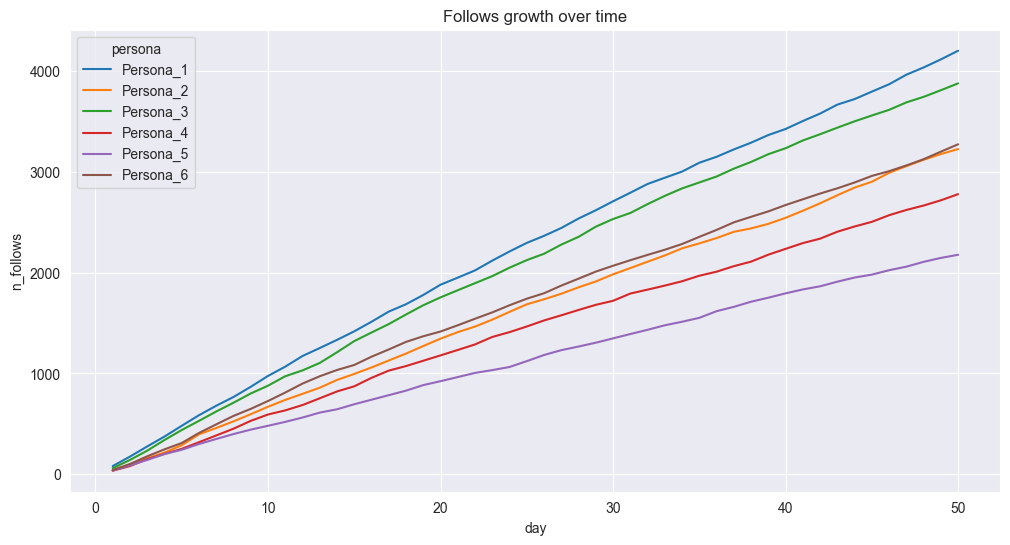

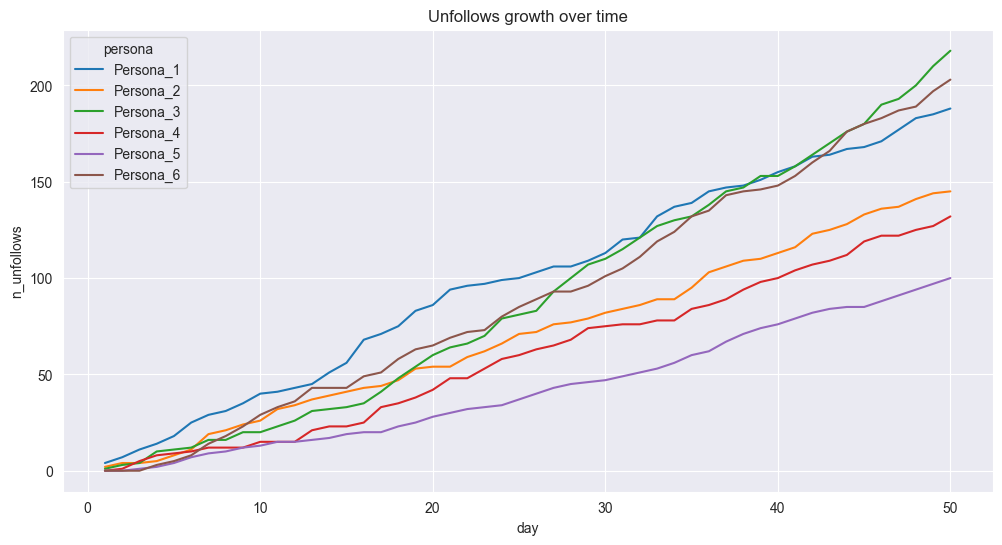

In [48]:
plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily,
    x='day',
    y='n_follows',
    hue='persona'
)

plt.title('Follows growth over time')
plt.show()

plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily,
    x='day',
    y='n_unfollows',
    hue='persona'
)

plt.title('Unfollows growth over time')
plt.show()

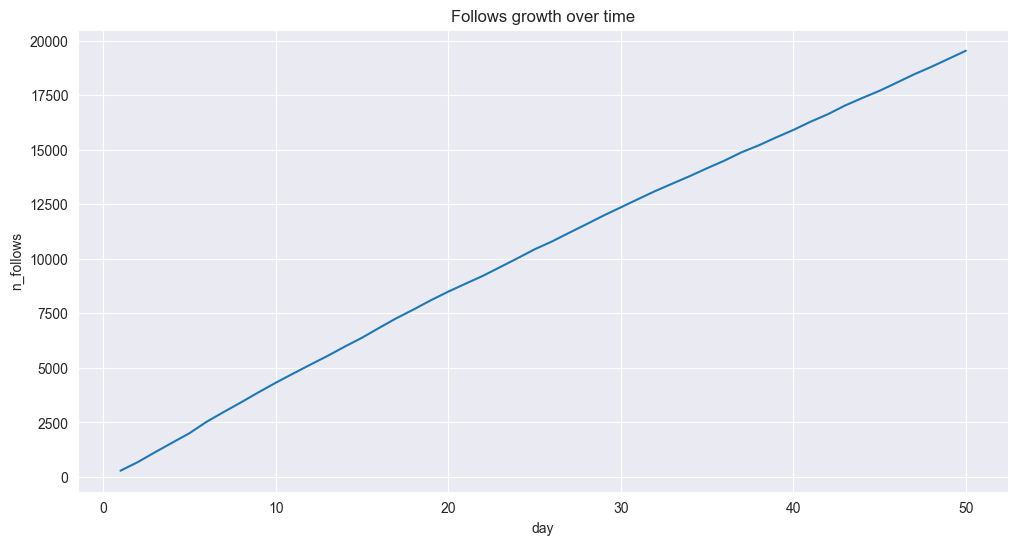

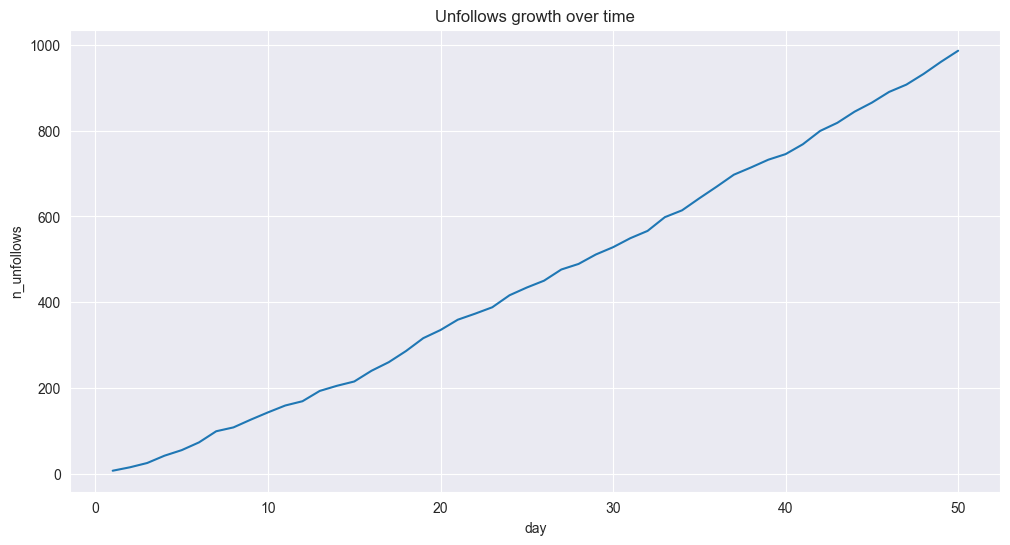

In [49]:
follows_daily_sum = follows_daily.groupby('day').agg(
    n_follows=('n_follows', 'sum'),
    n_unfollows=('n_unfollows', 'sum')
).reset_index()

plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily_sum,
    x='day',
    y='n_follows'
)

plt.title('Follows growth over time')
plt.show()

plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily_sum,
    x='day',
    y='n_unfollows'
)

plt.title('Unfollows growth over time')
plt.show()

In [50]:
# follows_daily_sum.to_csv('data/exp_set_2/follows_daily_sum.csv')

#### Posts

In [51]:
round_iter = 24
counts_daily = []

while round_iter <= max_round:
    posts_r = posts[posts['round'] <= round_iter]

    posts_per_persona = posts_r.groupby('persona').size().reset_index(name='n_posts')
    posts_per_persona['day'] = round_iter / 24

    counts_daily.append(posts_per_persona)
    round_iter += 24 # 1 round = 1 hour

posts_daily = pd.concat(counts_daily, ignore_index=True)

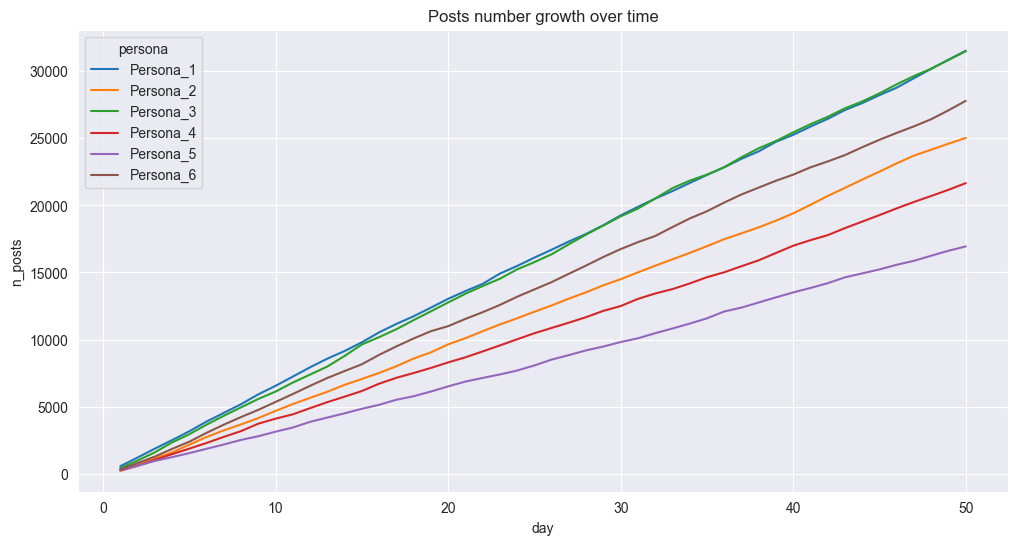

In [52]:
plt.figure(figsize = (12,6))

sns.lineplot(
    data=posts_daily,
    x='day',
    y='n_posts',
    hue='persona'
)

plt.title('Posts number growth over time')
plt.show()

In [53]:
posts_daily_sum = posts_daily.groupby('day').agg(
    n_posts=('n_posts', 'sum')
)
list(posts_daily_sum['n_posts'])

[2169,
 4884,
 7927,
 11037,
 14128,
 17550,
 20731,
 23789,
 26984,
 30001,
 33093,
 36333,
 39386,
 42493,
 45698,
 48976,
 52138,
 55166,
 58190,
 61276,
 64241,
 67077,
 70143,
 73230,
 76252,
 79273,
 82492,
 85624,
 88864,
 92001,
 95052,
 98153,
 101295,
 104361,
 107312,
 110478,
 113630,
 116635,
 119825,
 122895,
 126041,
 128993,
 132330,
 135329,
 138460,
 141671,
 144823,
 147879,
 151134,
 154400]

#### Neighborhood

In [46]:
def describe_neighborhood_over_time(follow_df, persona_dict, round_step=24):
    """
    Neighborhoods sizes analyses for personas groups over time. Generates plots.
    :param follow_df: follow table already merged with personas.
    """
    max_round = follow_df['round'].max()
    print(f"Rounds: {max_round}")
    print(f"Days: {max_round / 24}")

    round_iter = round_step
    counts_daily = []

    while round_iter <= max_round:
        follow_r = follow_df[follow_df['round'] <= round_iter]

        G, G_lcc = create_graph(follow_r)
        nx.set_node_attributes(G, persona_dict, "persona")

        persona_neighborhood_size = {}
        persona_groups = group_nodes_by_persona(G)

        for persona, nodes in persona_groups.items():
            counter = Counter()

            neighbors_set = set()

            for node in nodes:
                neighbors_set.update(G.neighbors(node))
                counter = Counter(G.nodes[n]["persona"] for n in neighbors_set)

            persona_neighborhood_size[persona] = len(neighbors_set)

        df = pd.DataFrame(
            list(persona_neighborhood_size.items()),
            columns=["persona", "neighborhood_size"]
        )

        df['day'] = round_iter // 24

        counts_daily.append(df)

        round_iter += round_step

    neighborhood_daily = pd.concat(counts_daily, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=neighborhood_daily,
        x='day',
        y='neighborhood_size',
        hue='persona'
    )
    plt.title('Neighborhood over time')
    plt.show()

    return neighborhood_daily

#### Jaccard similarity